In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Endocardial"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 16 s, sys: 2.29 s, total: 18.3 s
Wall time: 18.3 s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

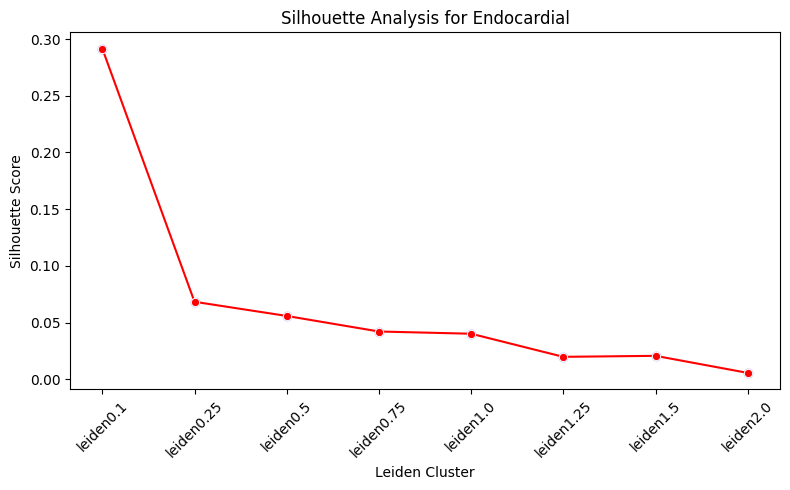

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

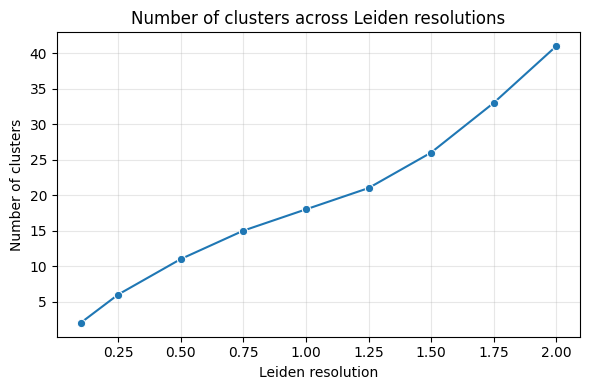

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.25

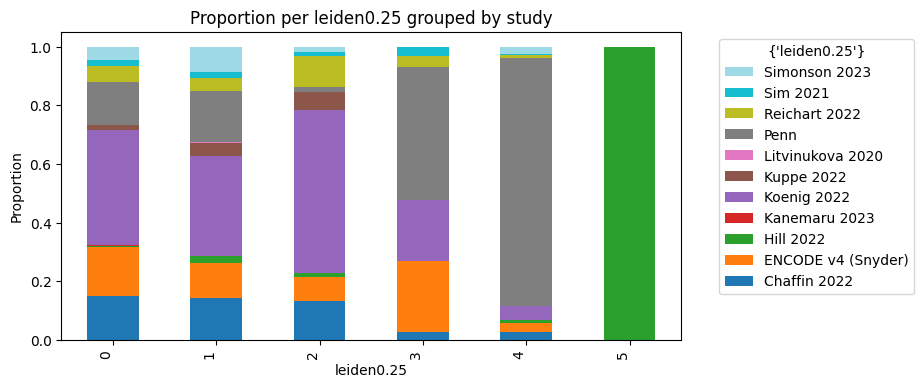

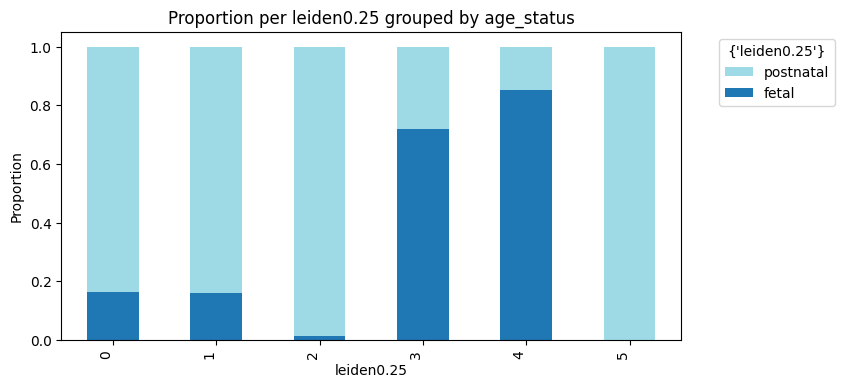

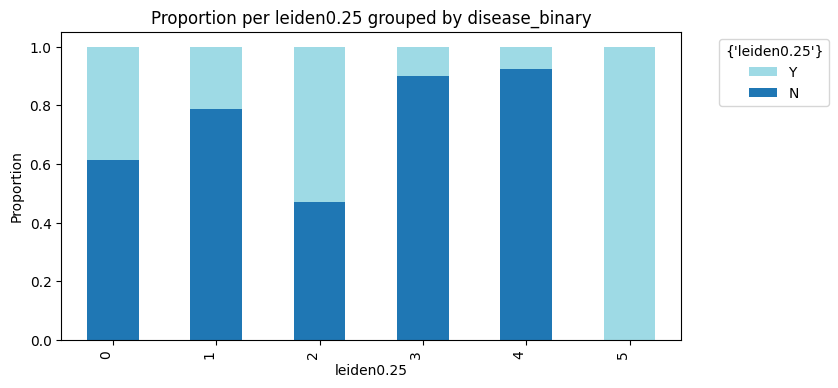

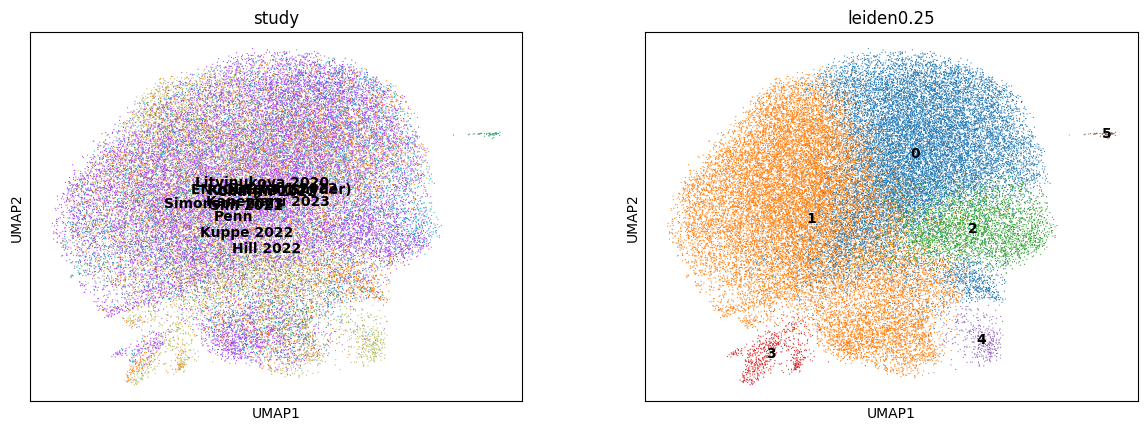

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

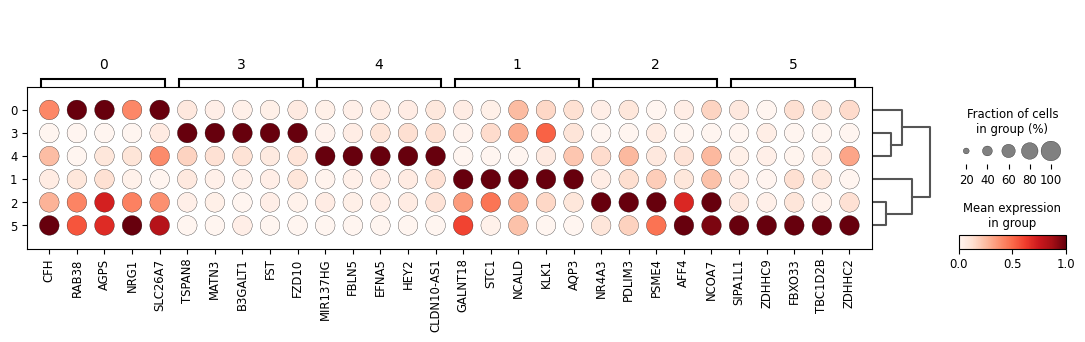

Counter({'1': 21190, '0': 16878, '2': 3398, '3': 677, '4': 393, '5': 46})
CPU times: user 4min 4s, sys: 2h 8min 5s, total: 2h 12min 9s
Wall time: 2min 19s


['leiden0.25',
 AnnData object with n_obs × n_vars = 42582 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
%%time
leiden_key = "leiden0.25"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

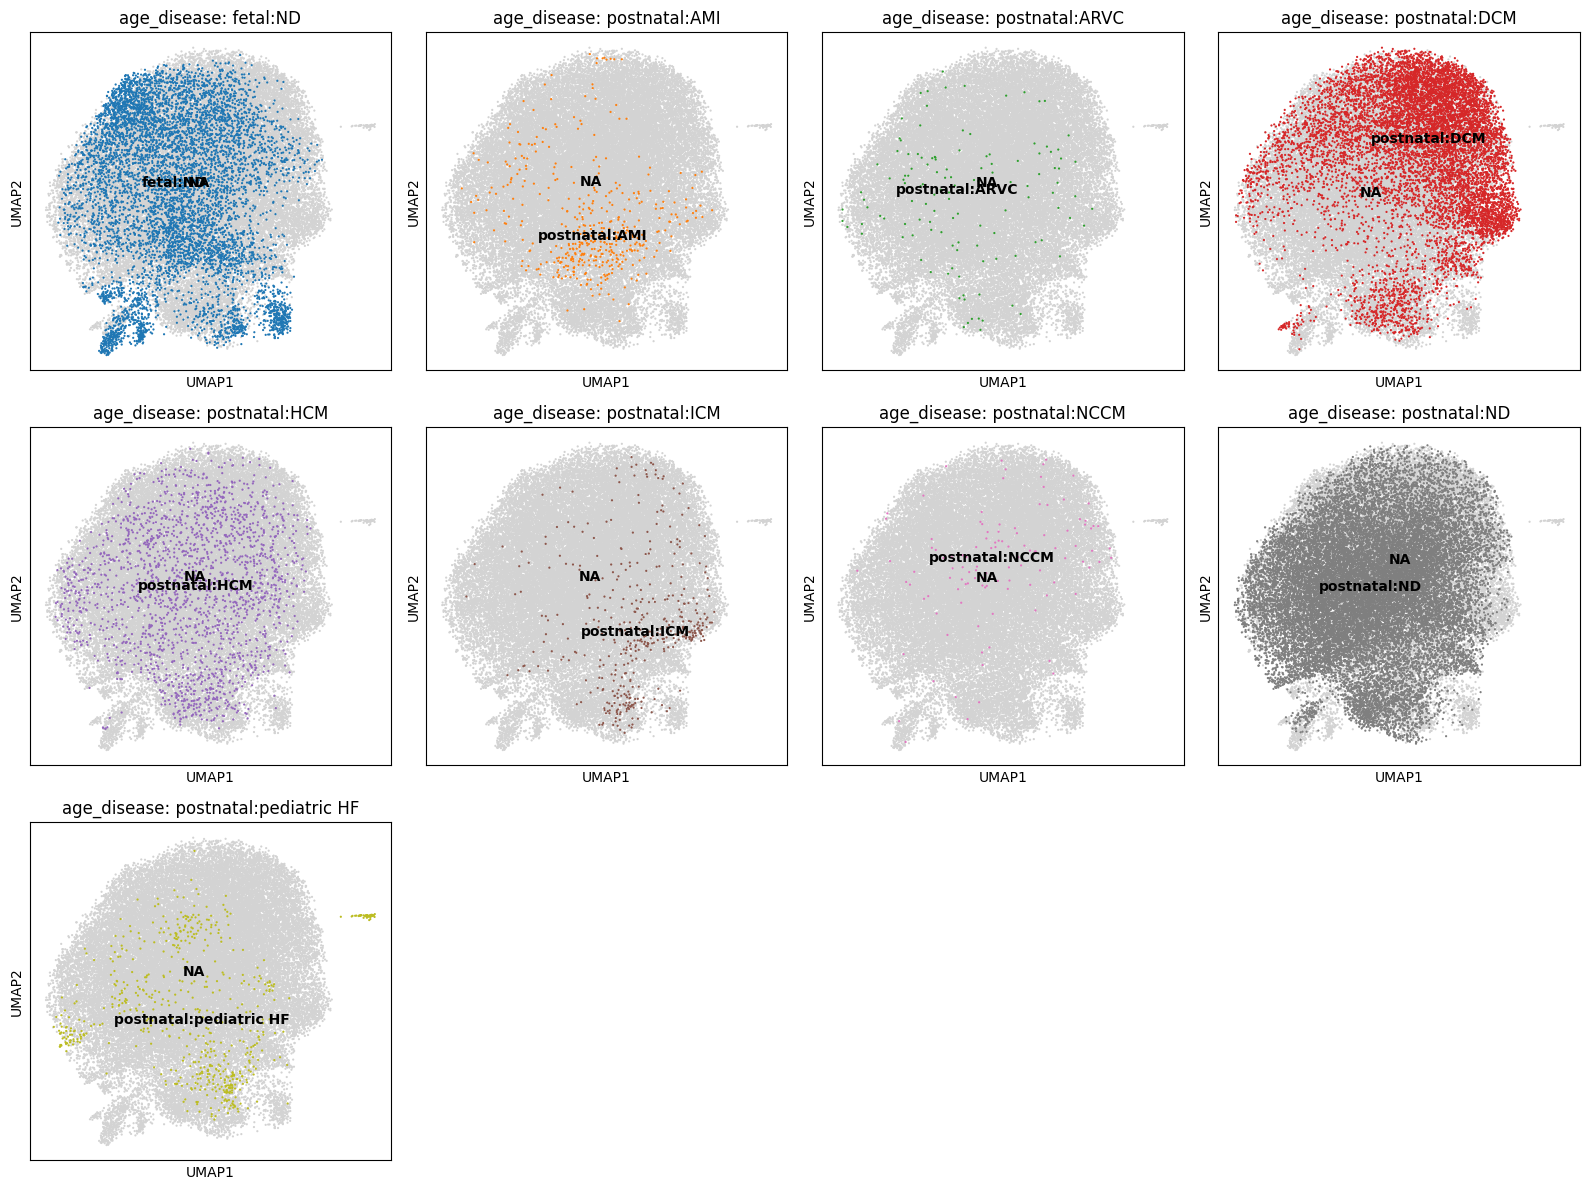

In [9]:
funcs.plot_umap_by_cluster(adata, metadata_key = "age_disease")

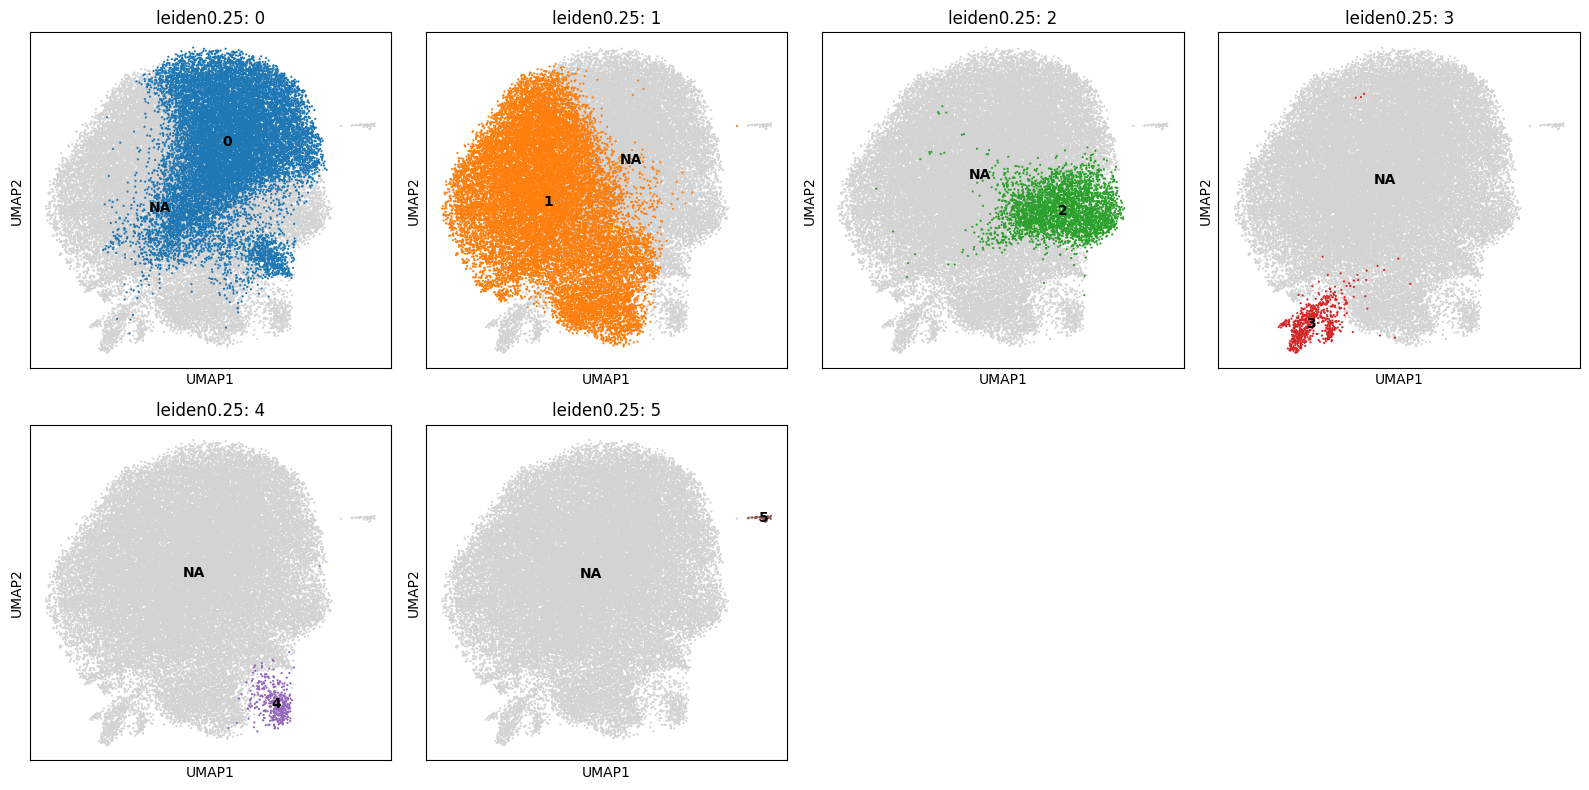

In [10]:
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key)

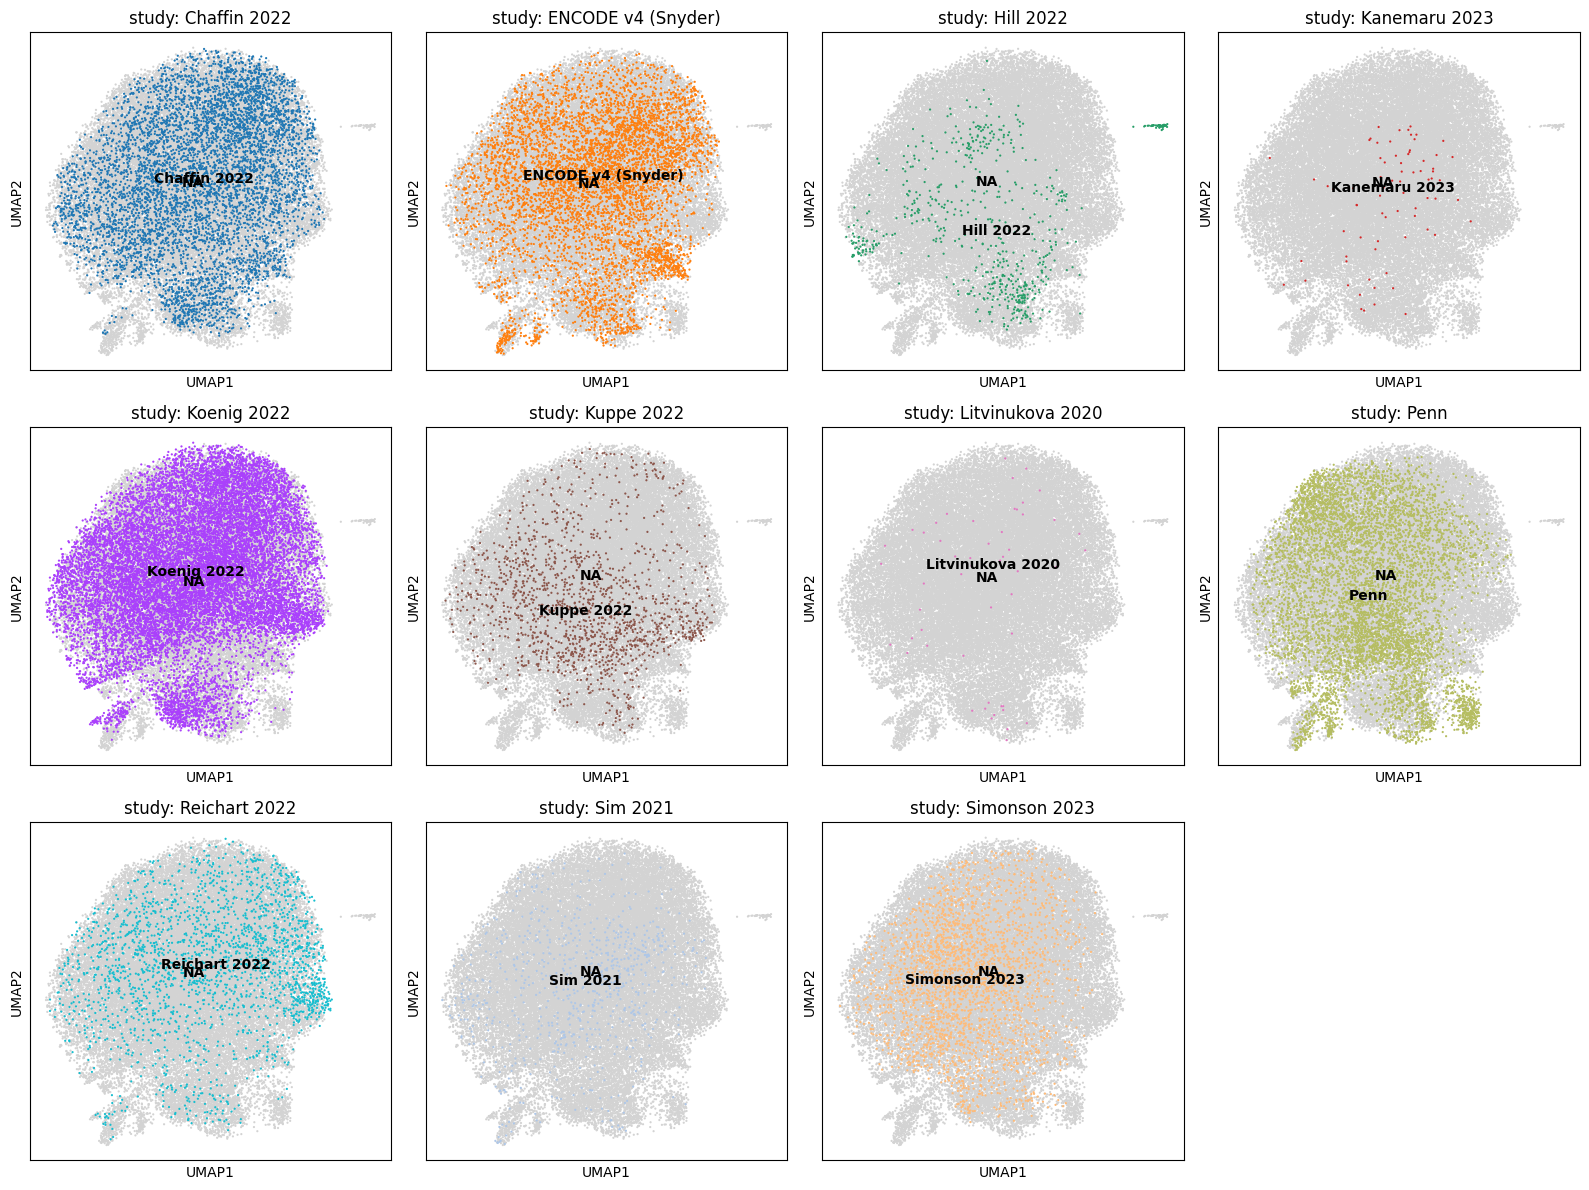

In [11]:
funcs.plot_umap_by_cluster(adata, metadata_key = "study")

### Examine enrichment along metadata categories

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


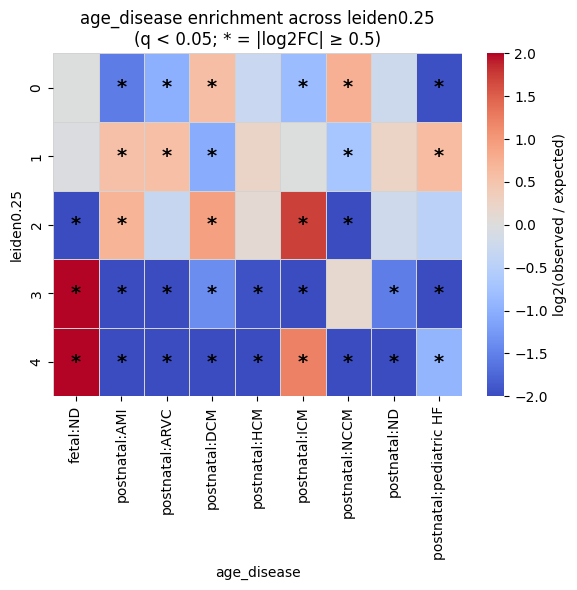

In [12]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=adata.obs,
    cluster_label=leiden_key,
    study_col="age_disease",
    min_cells=50, figsize_tuple = (6,6)
)

### Marker gene / ORA analysis

In [13]:
#sc.get.rank_genes_groups_df(adata, group="0").head(60)['names']

In [14]:
#sc.pl.umap(adata, color = "ERBB2",cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

Processing Cluster 0... Success.
Processing Cluster 1... Success.
Processing Cluster 2... Success.
Processing Cluster 3... Success.
Processing Cluster 4... Success.
Processing Cluster 5... Success.


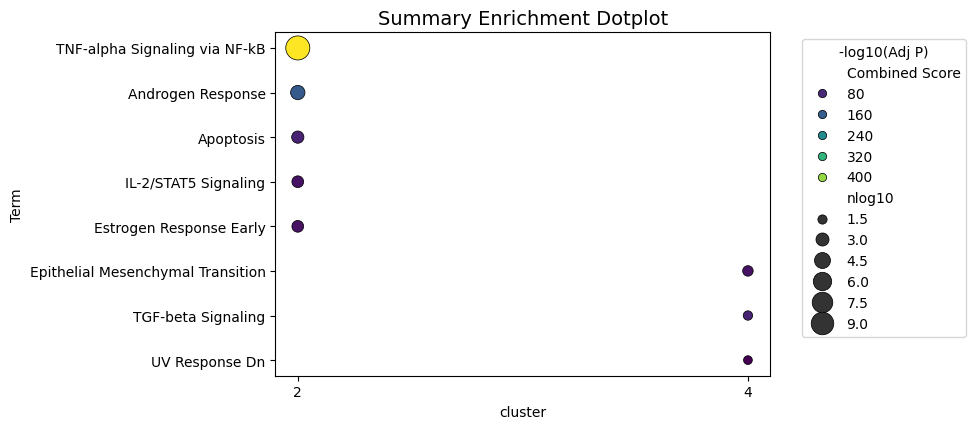

In [15]:
funcs.plot_all_cluster_enrichment(
     adata, cluster_key=leiden_key, 
     gene_sets=["MSigDB_Hallmark_2020"], outdir=None,top_n=100)

### Subcluster annotation

- Cluster 0 are valvular-like, expressing genes important for valve formation: NRG1/BMPR1B/BMP4/ELN
- Cluster 1 are arterial: DLL4/HES4/VEGFC 
- Cluster 2 are stress-activated: NR4A1/EGR3/CREM/DUSP2
- Cluster 3 are fetal-enriched: PROX1/WNT5A/LGR5
- Cluster 4 are also fetal-enriched, but mostly from one study; group with cluster 1
- Cluster 5 is a very small cluster from one study; do not annotate and group with cluster 1

In [24]:
adata.obs['subcluster'] = adata.obs[leiden_key].map(
    {"0": "Valvular-like",
     "1": "Arterial",
     "2": "Valvular-Activated",
     "3": "Fetal-enriched",
     "4": "Arterial",
     "5": "Arterial"
    }
)

subcluster_order = [
    "Arterial",
    "Fetal-enriched",
    "Valvular-like",
    "Valvular-Activated"
]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], 
    categories=subcluster_order, 
    ordered=True
)

subcluster_colors = {
    "Arterial": "red",          
    "Fetal-enriched": "pink",          
    "Valvular-Activated": "yellow",  
    "Valvular-like": "lightblue"    
}

# sync the colors with the uns dictionary for Scanpy plotting
adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

### Produce plots

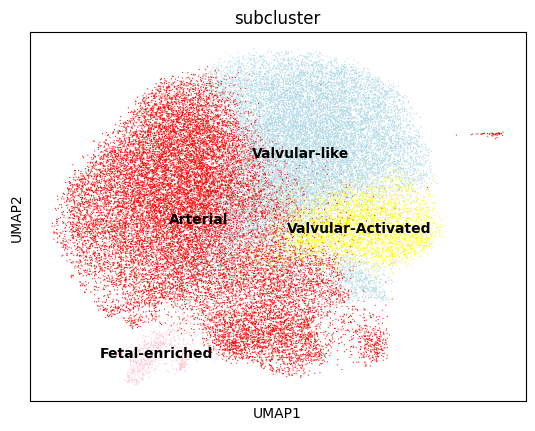

In [25]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

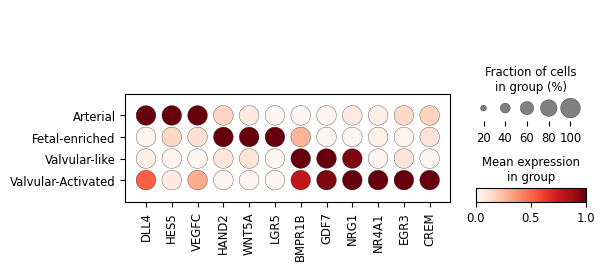

In [26]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["DLL4", "HES5", "VEGFC", 
                                      "HAND2", "WNT5A", "LGR5",
                                     "BMPR1B", "GDF7", "NRG1",
                                      "NR4A1", "EGR3", "CREM"], 
              groupby = "subcluster", show=False, standard_scale='var')
    plt.savefig(plots_dir + cell_type + "_subclustered_dotplot.pdf", bbox_inches="tight")

### Show enrichments by disease-age status and age group

In [19]:
adata_metadata = adata.obs

disease_filtered_metadata = adata_metadata[~adata_metadata['age_disease'].isin(["postnatal:ARVC", "postnatal:NCCM"])].copy()
for col in disease_filtered_metadata.select_dtypes('category').columns:
    disease_filtered_metadata[col] = disease_filtered_metadata[col].cat.remove_unused_categories()
    
ND_adata_metadata = adata_metadata[adata_metadata['disease_binary'] == "N"].copy()

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


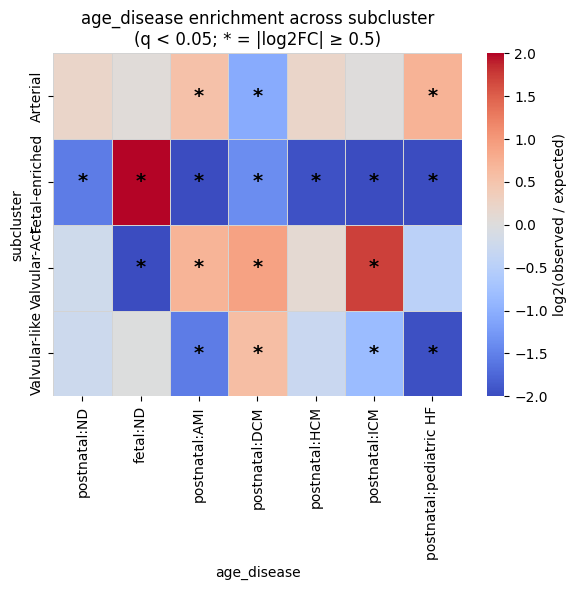

In [30]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=disease_filtered_metadata,
    cluster_label="subcluster",
    study_col="age_disease",
    metadata_order = ['postnatal:ND', 'fetal:ND', 'postnatal:AMI', 'postnatal:DCM', 
                      'postnatal:HCM', 'postnatal:ICM', 'postnatal:pediatric HF'],
    min_cells=50, figsize_tuple = (6,6)
)

plot.savefig(plots_dir + cell_type + "_subcluster_age_disease.pdf")

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


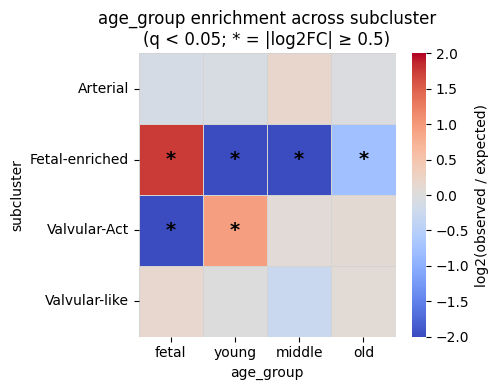

In [28]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=ND_adata_metadata,
    cluster_label="subcluster",
    metadata_order = ["fetal", "young", "middle", "old"],
    study_col="age_group",
    min_cells=50, figsize_tuple = (5,4)
)

plot.savefig(plots_dir + cell_type + "_subcluster_aging.pdf")

In [22]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

       subcluster  count  proportion
0        Arterial  21629    0.507938
1   Valvular-like  16878    0.396365
2    Valvular-Act   3398    0.079799
3  Fetal-enriched    677    0.015899


### Save metadata

In [23]:
adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")